<a href="https://colab.research.google.com/github/James-S-Wood/2-counter/blob/master/Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print ('Hello World')

Hello World


In [ ]:
print ('Jupyter Notebook is fun and easy to use')

Jupyter Notebook is fun and easy to use


# This is the biggest header
## This is the second biggest

In [ ]:
print(df['severity'].value_counts())

/tmp/ipykernel_286/859709832.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='severity', palette='viridis')


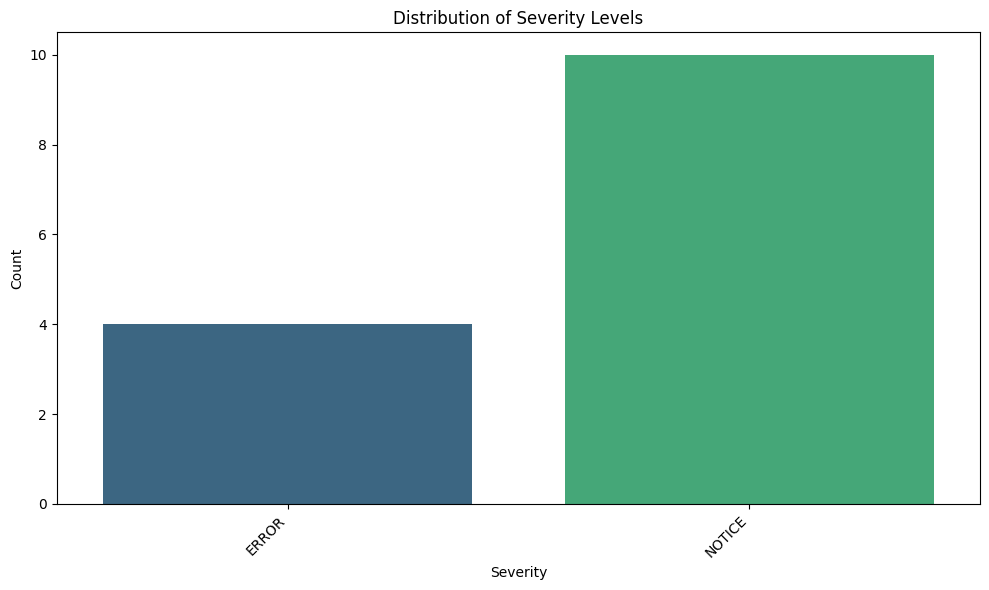

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot for the 'severity' column
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='severity', palette='viridis')
plt.title('Distribution of Severity Levels')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Impute 'protoPayload.status.code' with its mode (which is 9, based on previous df.describe() output)
# This column appears to be numerical, and all existing values were 9.
if 'protoPayload.status.code' in df.columns:
    df['protoPayload.status.code'] = df['protoPayload.status.code'].fillna(9)

# Identify other columns with missing values (excluding 'protoPayload.status.code')
columns_to_impute_unknown = df.columns[df.isnull().any()].tolist()
if 'protoPayload.status.code' in columns_to_impute_unknown:
    columns_to_impute_unknown.remove('protoPayload.status.code')

# Impute remaining missing values with 'Unknown'
for col in columns_to_impute_unknown:
    if df[col].dtype == 'object': # Only impute object/categorical types with 'Unknown'
        df[col] = df[col].fillna('Unknown')
    else: # For any other numeric types that might still have NaNs (though less likely after status.code)
        # For simplicity, we'll also fill these with 'Unknown' as a string if they were not explicitly handled
        # In a real scenario, you might want to fill numerical NaNs with mean/median/0 etc.
        df[col] = df[col].fillna('Unknown')

print("Missing values imputed. Displaying updated DataFrame head:")
display(df.head())

print("\nMissing values after imputation:")
display(df.isnull().sum())

Missing values imputed. Displaying updated DataFrame head:


,insertId,logName,operation.first,operation.id,operation.last,operation.producer,protoPayload.authenticationInfo.principalEmail,protoPayload.authorizationInfo.granted,protoPayload.authorizationInfo.permission,protoPayload.authorizationInfo.permissionType,...,receiveLocation,receiveTimestamp,resource.labels.database_id,resource.labels.method,resource.labels.project_id,resource.labels.region,resource.labels.service,resource.type,severity,timestamp
0,3wksdzdan2v,'projects/learning-project-2025/logs/cloudaudi...,Unknown,Unknown,Unknown,Unknown,'appletopia@gmail.com,"'[true,true,true,true]","'[""serviceusage.services.enable"",""serviceusage...","'[""ADMIN_WRITE"",""ADMIN_WRITE"",""ADMIN_WRITE"",""A...",...,Unknown,'2026-03-03T11:13:30.773670854Z,Unknown,google.api.serviceusage.v1.ServiceUsage.BatchE...,'learning-project-2025,Unknown,serviceusage.googleapis.com,audited_resource,ERROR,'2026-03-03T11:13:30.047042Z
1,'-gd9dtcd1oow,'projects/learning-project-2025/logs/cloudaudi...,Unknown,Unknown,Unknown,Unknown,'appletopia@gmail.com,[true],"'[""cloudsql.instances.create""]","'[""ADMIN_WRITE""]",...,Unknown,'2026-03-03T11:11:54.099476070Z,Unknown,Unknown,'learning-project-2025,'us-east1,Unknown,cloudsql_database,NOTICE,'2026-03-03T11:11:53.702119Z
2,fjmsygdkz5t,'projects/learning-project-2025/logs/cloudaudi...,True,operations/noop.DONE_OPERATION,True,serviceusage.googleapis.com,'appletopia@gmail.com,[true],"'[""serviceusage.services.enable""]","'[""ADMIN_WRITE""]",...,Unknown,'2026-03-03T11:09:16.950417499Z,Unknown,google.api.serviceusage.v1.ServiceUsage.Enable...,'learning-project-2025,Unknown,serviceusage.googleapis.com,audited_resource,NOTICE,'2026-03-03T11:09:15.852037Z
3,11ieyopdkw7l,'projects/learning-project-2025/logs/cloudaudi...,True,operations/noop.DONE_OPERATION,True,serviceusage.googleapis.com,'appletopia@gmail.com,[true],"'[""serviceusage.services.enable""]","'[""ADMIN_WRITE""]",...,Unknown,'2026-03-03T11:09:16.846614645Z,Unknown,google.api.serviceusage.v1.ServiceUsage.Enable...,'learning-project-2025,Unknown,serviceusage.googleapis.com,audited_resource,NOTICE,'2026-03-03T11:09:15.752676Z
4,th1zc9d9c85,'projects/learning-project-2025/logs/cloudaudi...,True,operations/noop.DONE_OPERATION,True,serviceusage.googleapis.com,'appletopia@gmail.com,[true],"'[""serviceusage.services.enable""]","'[""ADMIN_WRITE""]",...,Unknown,'2026-03-03T11:09:16.764443044Z,Unknown,google.api.serviceusage.v1.ServiceUsage.Enable...,'learning-project-2025,Unknown,serviceusage.googleapis.com,audited_resource,NOTICE,'2026-03-03T11:09:15.696210Z



Missing values after imputation:


,0
insertId,0
logName,0
operation.first,0
operation.id,0
operation.last,0
operation.producer,0
protoPayload.authenticationInfo.principalEmail,0
protoPayload.authorizationInfo.granted,0
protoPayload.authorizationInfo.permission,0
protoPayload.authorizationInfo.permissionType,0


In [6]:
print('Missing values before handling:')
display(df.isnull().sum())

Missing values before handling:


,0
insertId,0
logName,0
operation.first,5
operation.id,5
operation.last,5
operation.producer,5
protoPayload.authenticationInfo.principalEmail,0
protoPayload.authorizationInfo.granted,0
protoPayload.authorizationInfo.permission,0
protoPayload.authorizationInfo.permissionType,0


From the output above, you can see the count of missing values for each column. Depending on the amount of missing data and the nature of the column, you have several options:

1.  **Drop rows with missing values**: If only a small percentage of rows have missing values, you might choose to remove those rows.
2.  **Drop columns with missing values**: If a column has a very high percentage of missing values (e.g., more than 50-70%), it might be best to drop the entire column.
3.  **Impute missing values**: For numerical columns, you can replace missing values with the mean, median, or a specific value. For categorical columns, you can replace them with the mode or a new category like 'Unknown'.

Let me know which strategy you'd like to apply, or I can suggest one based on the missing data percentages.

In [5]:
display(df.describe())

,protoPayload.redactions.field,protoPayload.redactions.reason,protoPayload.redactions.type,protoPayload.requestMetadata.destinationAttributes,protoPayload.requestMetadata.requestAttributes.auth,protoPayload.status.code,receiveLocation,resource.labels.database_id
count,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN


In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/downloaded-logs-20260303-062914.csv'

try:
    df = pd.read_csv(file_path)
    print(f'DataFrame loaded successfully from {file_path}!')
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

DataFrame loaded successfully from /content/drive/MyDrive/downloaded-logs-20260303-062914.csv!


,insertId,logName,operation.first,operation.id,operation.last,operation.producer,protoPayload.authenticationInfo.principalEmail,protoPayload.authorizationInfo.granted,protoPayload.authorizationInfo.permission,protoPayload.authorizationInfo.permissionType,...,receiveLocation,receiveTimestamp,resource.labels.database_id,resource.labels.method,resource.labels.project_id,resource.labels.region,resource.labels.service,resource.type,severity,timestamp
0,3wksdzdan2v,'projects/learning-project-2025/logs/cloudaudi...,NaN,NaN,NaN,NaN,'appletopia@gmail.com,"'[true,true,true,true]","'[""serviceusage.services.enable"",""serviceusage...","'[""ADMIN_WRITE"",""ADMIN_WRITE"",""ADMIN_WRITE"",""A...",...,NaN,'2026-03-03T11:13:30.773670854Z,NaN,google.api.serviceusage.v1.ServiceUsage.BatchE...,'learning-project-2025,NaN,serviceusage.googleapis.com,audited_resource,ERROR,'2026-03-03T11:13:30.047042Z
1,'-gd9dtcd1oow,'projects/learning-project-2025/logs/cloudaudi...,NaN,NaN,NaN,NaN,'appletopia@gmail.com,[true],"'[""cloudsql.instances.create""]","'[""ADMIN_WRITE""]",...,NaN,'2026-03-03T11:11:54.099476070Z,NaN,NaN,'learning-project-2025,'us-east1,NaN,cloudsql_database,NOTICE,'2026-03-03T11:11:53.702119Z
2,fjmsygdkz5t,'projects/learning-project-2025/logs/cloudaudi...,True,operations/noop.DONE_OPERATION,True,serviceusage.googleapis.com,'appletopia@gmail.com,[true],"'[""serviceusage.services.enable""]","'[""ADMIN_WRITE""]",...,NaN,'2026-03-03T11:09:16.950417499Z,NaN,google.api.serviceusage.v1.ServiceUsage.Enable...,'learning-project-2025,NaN,serviceusage.googleapis.com,audited_resource,NOTICE,'2026-03-03T11:09:15.852037Z
3,11ieyopdkw7l,'projects/learning-project-2025/logs/cloudaudi...,True,operations/noop.DONE_OPERATION,True,serviceusage.googleapis.com,'appletopia@gmail.com,[true],"'[""serviceusage.services.enable""]","'[""ADMIN_WRITE""]",...,NaN,'2026-03-03T11:09:16.846614645Z,NaN,google.api.serviceusage.v1.ServiceUsage.Enable...,'learning-project-2025,NaN,serviceusage.googleapis.com,audited_resource,NOTICE,'2026-03-03T11:09:15.752676Z
4,th1zc9d9c85,'projects/learning-project-2025/logs/cloudaudi...,True,operations/noop.DONE_OPERATION,True,serviceusage.googleapis.com,'appletopia@gmail.com,[true],"'[""serviceusage.services.enable""]","'[""ADMIN_WRITE""]",...,NaN,'2026-03-03T11:09:16.764443044Z,NaN,google.api.serviceusage.v1.ServiceUsage.Enable...,'learning-project-2025,NaN,serviceusage.googleapis.com,audited_resource,NOTICE,'2026-03-03T11:09:15.696210Z


In [3]:
import os

drive_path = '/content/drive/MyDrive'

# Check if Google Drive is mounted
if os.path.exists(drive_path):
    print(f"Listing contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print("Google Drive is not mounted. Please run the cell to mount it first.")
    print("from google.colab import drive")
    print("drive.mount('/content/drive')")

Listing contents of '/content/drive/MyDrive':
Cherokee
Barbara
Resume
Greg
Me Myself & I
ART
Writings
Misc
Google Photos
Play Books Notes
Catholic 
Flute Stuff
Colab Notebooks
Tech Certificates
Tech Books
IMPORTANT
Flintlake Apartments
Oracle_DevOps
Camera
Screenshots
Webcamoid
AWS Keys
College Transcripts
Health Insurance
Teacher_Resources
Wallpaper
Excel Learning Files
bq-results-20250322-001359-1742602479236
The Jefferson Project
Yale Divinity School Application
Data Analytics 
Bible Study and Reference
Yale_Bible_Study
Episcopal_Church
House-Photos
IMPORTANT (1)
AWS_Cloud_Institute
Data-Files-Projects
Amazon_Keys
DIRT
Google_Cloud_Certifications
XNXX
JAMES_WOOD
NC_Teachers_of_Tomorrow
CSV_Files_Data_Sets
c-sharp-10-fundamentals
Python-Learning-Materials
Screenplays
Saved from Chrome
Top 10 Most Expensive Real Estate Markets.gsheet
Baby Ruth vs. Snickers Candy Bars.gsheet
downloaded-logs-20260303-062914.csv
GCP-logs-2026_03_03-062914.gsheet


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After running the cell above, you will be prompted to authorize Google Drive access. Once authorized, your Drive will be mounted at `/content/drive`. You can then navigate to your files. For example, if you have a CSV file named `my_data.csv` in the root of 'My Drive', its path would be `/content/drive/MyDrive/my_data.csv`.

In [2]:
import pandas as pd

# Example: Load a CSV file from your Google Drive
# Replace 'my_data.csv' with the actual path to your file in Google Drive
try:
    df = pd.read_csv('/content/drive/MyDrive/my_data.csv')
    print('DataFrame loaded successfully!')
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'my_data.csv' was not found in your Google Drive. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: The file 'my_data.csv' was not found in your Google Drive. Please check the path and try again.
